# Pricing weather derivatives: how good is a temperature model, in risk and in dollars?

We evaluate six temperature generators on the same HDD call contracts through **two parts**:

- **Part A, risk / distribution (primary).** A price is the discounted mean of a *predictive distribution* of payoffs (climatic indexes, HDD here). We compare each model by the **distribution it produces** and its **dispersion**. This tells us which model calibrates the risk correctly, without needing any realized outcome.

- **Part B, economic backtest (secondary).** We confront each model's *price* with the *realized payoff* over a grid of past contracts. Intuitive but limited: a realized payoff is **a single draw, not a distribution**, so it is *suggestive*, not decisive.

**The six generators.** `burn` (the empirical distribution of past realized winters, a model-free
reference), `clim` (deterministic seasonal-mean analyst, the $\theta$ component), `OU`, and `ridge / rf / xgb` (conditional
ML). Contract: HDD call, Nov→Mar, priced Oct 1st, tick $\alpha=20\$$, $r=1\%$.
**Grid:** 7 cities × 5 test winters = 35 contracts.

In [1]:
import sys; sys.path.append("../src")
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, skew, kurtosis

from config import CLEANED_DIR, BASE_TEMP, TRAIN_END
from ou_simulation import load_ou_params, simulate_ou, x0_from_dataset
from ml_simulation import simulate_ml
from pricing import hdd_cumulative, get_season_windows
from temperature_mc import load_city, load_model, recursive_errors, make_pool
from pricing_contest import friedman_nemenyi, bootstrap_gains, ORDER, TICK

plt.rcParams.update({"font.family": "serif", "font.size": 9, "axes.titlesize": 10,
                     "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
COLORS = {"burn": "#555", "clim": "#999", "ou": "#1f4e79",
          "ridge": "#2ca02c", "rf": "#d4882b", "xgb": "#9467bd"}
R = 0.01

res = pd.read_csv("../outputs/pricing_contest.csv")
res["APE"] = (res.mu_H - res.H_real).abs() / res.H_real
MODELS = [m for m in ORDER if m in set(res.model)]
CITIES, WINTERS = sorted(res.city.unique()), sorted(res.winter.unique())
print(f"{len(res)} rows = {len(MODELS)} models x {len(CITIES)} cities x {len(WINTERS)} winters")

210 rows = 6 models x 7 cities x 5 winters


# Part A: Climatic index distribution

## The burn distribution of each city (its climatological HDD risk)

The **burn distribution is not modelled**. It is simply the set of **realized cumulative HDD of all
past winters** of that city (≈75 winters, 1951 to 2025). Its spread $\sigma_H$ *is* the true
inter-annual variability of the heating season, by construction, which is exactly why it is the
reference benchmark for dispersion.

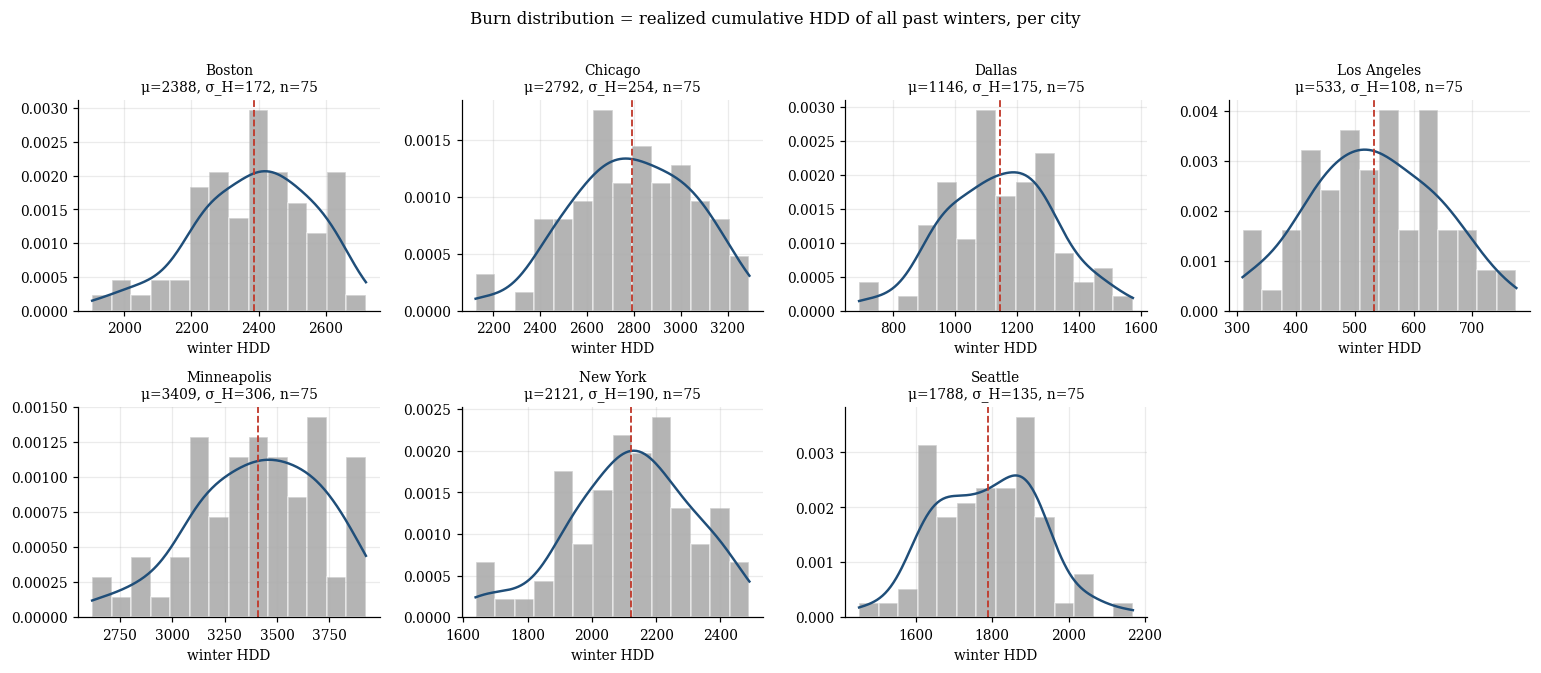

In [2]:
def winter_hdds(slug):
    d = pd.read_csv(f"{CLEANED_DIR}/{slug}_ou_dataset.csv", parse_dates=["DATE"]).set_index("DATE")
    out = {}
    for y in range(d.index.year.min() + 1, d.index.year.max() + 1):
        w = d.loc[f"{y-1}-11-01":f"{y}-03-31", "T"]
        if w.notna().sum() >= 120:
            out[y] = float(np.maximum(BASE_TEMP - w, 0).sum())
    return pd.Series(out)

burn = {c: winter_hdds(c) for c in CITIES}     # all past winters, per city

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, c in zip(axes.flat, CITIES):
    h = burn[c].values
    ax.hist(h, bins=14, density=True, color="#777", alpha=0.55, edgecolor="white")
    g = np.linspace(h.min(), h.max(), 200)
    ax.plot(g, gaussian_kde(h)(g), color="#1f4e79", lw=1.6)
    ax.axvline(h.mean(), color="#c0392b", ls="--", lw=1.2)
    ax.set_title(f"{c.replace('_',' ').title()}\nμ={h.mean():.0f}, σ_H={h.std():.0f}, n={len(h)}", fontsize=9)
    ax.set_xlabel("winter HDD")
axes.flat[-1].axis("off")
fig.suptitle("Burn distribution = realized cumulative HDD of all past winters, per city", y=1.01)
fig.tight_layout()

Using *all* winters maximizes the sample (robust $\sigma_H$) but the older winters (1950s to 80s) are colder, so the **level (mean) is cold-shifted** by +50 to +280 HDD versus the recent decade. For the *spread* this is fine (and even closer to the true inter-annual
variability). For *pricing the strike*, a recent (or detrended) window is used to avoid the cold bias.

Burn evolution and the warming trend :

 Each city's realized winter HDD since 1950, with its linear trend. Every city warms, from $-18$ (LA) to $-62$ (Minneapolis) HDD/decade. Detrending (taking the residual scatter) removes only **~6 to 12 % of $\sigma_H$**: the bulk of the inter-annual spread is genuine climate noise, not the trend. The trend bites harder on the **level** (a long-window mean over-states HDD → biases the strike $K$ high) than on the dispersion, which is why a desk prices off a *recent / detrended* level, not the 1950 to 2024 average.

,slope/decade,sigma_raw,sigma_detrended,reduction_%
city,,,,
boston,-26.6,173,164,5.7
chicago,-52.5,256,229,10.6
dallas,-38.0,176,155,11.8
los_angeles,-18.0,109,102,6.7
minneapolis,-62.4,308,277,10.3
new_york,-37.0,191,174,9.3
seattle,-27.2,136,123,10.0


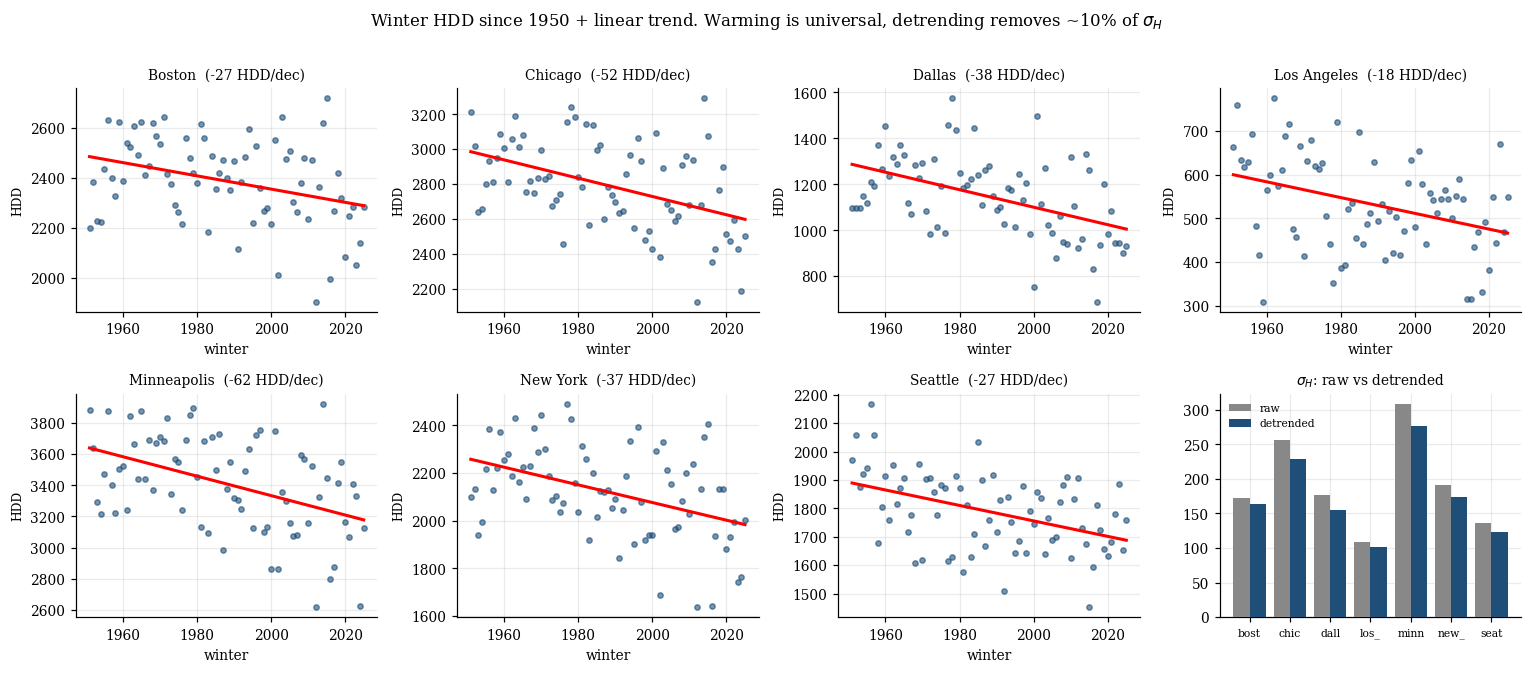

In [3]:
# Winter HDD since 1950 + linear trend (polyfit) per city, and the detrend effect on sigma_H
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
summ = []
for ax, c in zip(axes.flat, CITIES):
    yrs = burn[c].index.values.astype(float); h = burn[c].values
    b, a = np.polyfit(yrs, h, 1); fit = a + b * yrs; resid = h - fit
    ax.scatter(yrs, h, s=12, color="#1f4e79", alpha=0.6, zorder=3)
    ax.plot(yrs, fit, "r-", lw=2, zorder=4)
    ax.set_title(f"{c.replace('_',' ').title()}  ({b*10:+.0f} HDD/dec)", fontsize=9)
    ax.set_xlabel("winter"); ax.set_ylabel("HDD", fontsize=8)
    summ.append({"city": c, "slope/decade": round(b*10, 1),
                 "sigma_raw": round(h.std(ddof=1)), "sigma_detrended": round(resid.std(ddof=1)),
                 "reduction_%": round(100*(h.std(ddof=1)-resid.std(ddof=1))/h.std(ddof=1), 1)})
s = pd.DataFrame(summ); xx = np.arange(len(s)); ax = axes.flat[7]
ax.bar(xx-0.2, s.sigma_raw, 0.4, label="raw", color="#888", zorder=3)
ax.bar(xx+0.2, s.sigma_detrended, 0.4, label="detrended", color="#1f4e79", zorder=3)
ax.set_xticks(xx, [c[:4] for c in s.city], fontsize=7)
ax.set_title("$\\sigma_H$: raw vs detrended", fontsize=9); ax.legend(fontsize=7, frameon=False)
fig.suptitle("Winter HDD since 1950 + linear trend. Warming is universal, detrending removes ~10% of $\\sigma_H$", y=1.01)
fig.tight_layout()
display(s.set_index("city"))

## The conditional models vs the two desk burns

We benchmark each model's $\sigma_H$ against **two desk burns**: the **normal** burn (the raw
inter-annual spread of past winters) and the **detrended** burn (warming-adjusted, the spread once
the trend of the previous section is removed). The pattern is universal: in every city, OU and the
ML models produce a **narrower** HDD distribution than *both* burns, the ML i.i.d. resampling the
most. Because a call's price tracks $\sigma_H$, a narrower model prices the winter risk lower.

,burn_normal,burn_detr,ou,rf,rf / burn_detr
boston,173.0,164.0,118.0,54.0,0.33
chicago,256.0,229.0,169.0,66.0,0.29
dallas,176.0,155.0,136.0,59.0,0.38
los_angeles,109.0,102.0,74.0,24.0,0.24
minneapolis,308.0,277.0,195.0,76.0,0.27
new_york,191.0,174.0,130.0,54.0,0.31
seattle,136.0,123.0,92.0,36.0,0.29


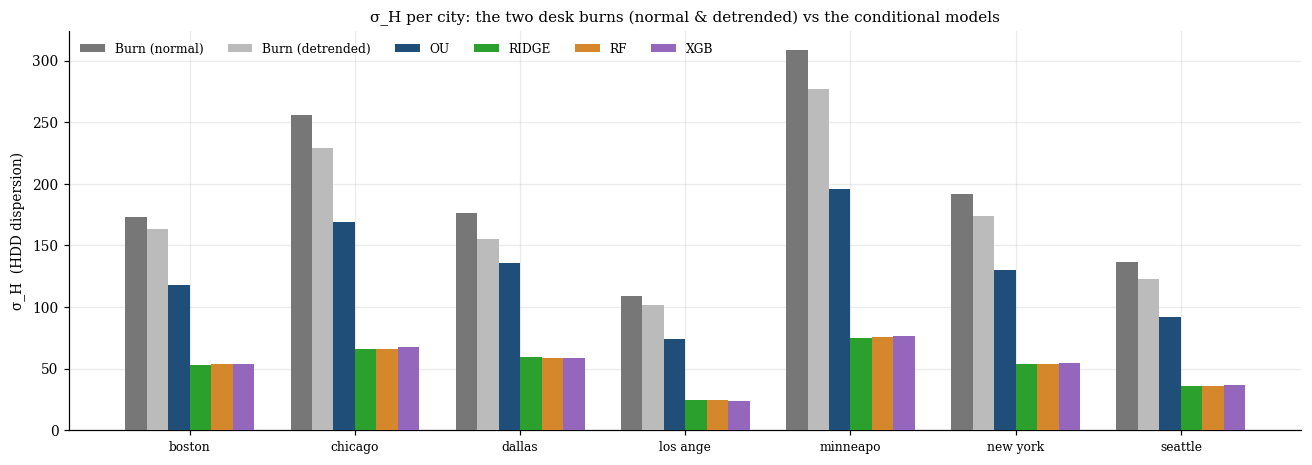

In [4]:
yr = {c: burn[c].index.values.astype(float) for c in CITIES}
sig_normal = pd.Series({c: burn[c].std(ddof=1) for c in CITIES})
sig_detr   = pd.Series({c: (burn[c].values - np.polyval(np.polyfit(yr[c], burn[c].values, 1), yr[c])).std(ddof=1)
                        for c in CITIES})
sig_mod = res.groupby(["city", "model"])["sigma_H"].mean().unstack()[["ou", "ridge", "rf", "xgb"]]

fig, ax = plt.subplots(figsize=(12, 4.3))
x = np.arange(len(CITIES)); w = 0.13
ax.bar(x - 2.5*w, sig_normal[CITIES].values, w, label="Burn (normal)",    color="#777", zorder=3)
ax.bar(x - 1.5*w, sig_detr[CITIES].values,   w, label="Burn (detrended)", color="#bbb", zorder=3)
for i, m in enumerate(["ou", "ridge", "rf", "xgb"]):
    ax.bar(x + (i - 0.5)*w, sig_mod.loc[CITIES, m].values, w, label=m.upper(), color=COLORS[m], zorder=3)
ax.set_xticks(x, [c.replace("_", " ")[:8] for c in CITIES], fontsize=8)
ax.set_ylabel("σ_H  (HDD dispersion)")
ax.set_title("σ_H per city: the two desk burns (normal & detrended) vs the conditional models")
ax.legend(frameon=False, ncols=6, fontsize=8); fig.tight_layout()
display(pd.DataFrame({"burn_normal": sig_normal.round(0), "burn_detr": sig_detr.round(0),
                     "ou": sig_mod["ou"].round(0), "rf": sig_mod["rf"].round(0),
                     "rf / burn_detr": (sig_mod["rf"] / sig_detr).round(2)}))

## Dispersion sets the price (focus: Chicago, near-ATM)

For one contract we price the call with every model. The strike is near the mean (ATM), so the
**price is governed by $\sigma_H$**, not the mean: a narrow distribution barely pokes above $K$, so
it under-prices the option.

  V1 (Barnor) : 27720 lignes × 50 features | lignes avec NaN : 2183


,sigmaH,price
burn,255.8,2073.1
ou,173.1,666.5
ridge,66.5,0.0
rf,65.5,0.0
xgb,68.3,0.0


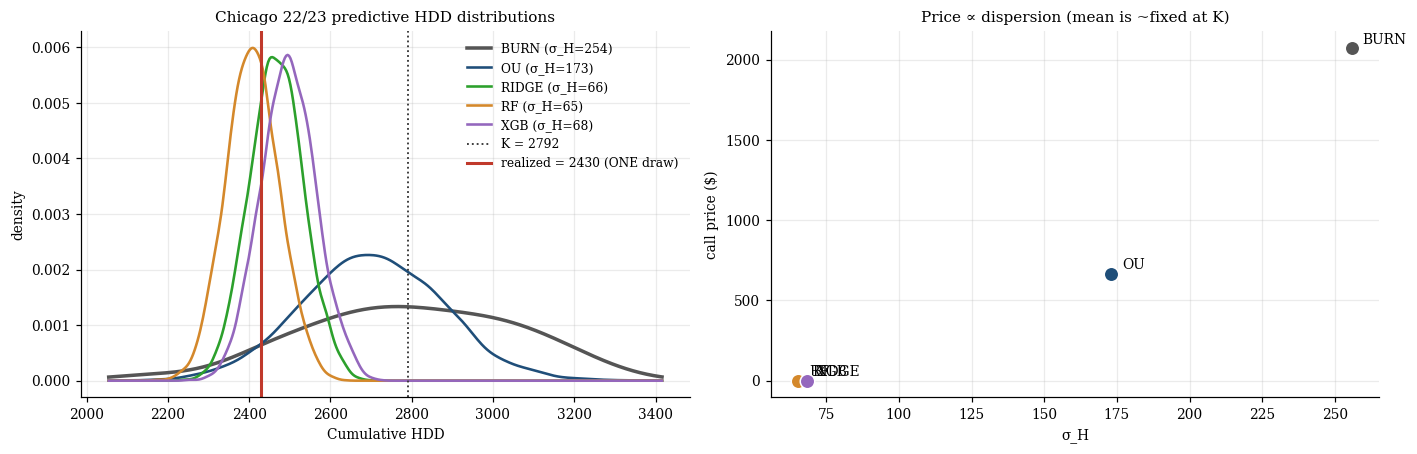

In [5]:
CITY, S, START, END, N = "chicago", "2022-10-01", "2022-11-01", "2023-03-31", 6000
ttm = (pd.Timestamp(END) - pd.Timestamp(S)).days / 365
df, feat = load_city(CITY); params = load_ou_params(CITY)
K = round(burn[CITY].mean())                       # ATM on the full-history burn mean

H = {"burn": burn[CITY].values,
     "ou": hdd_cumulative(simulate_ou(params, S, END, n_sims=N,
            X0=x0_from_dataset(CITY, S), seed=1).loc[START:END]).to_numpy()}
for m in ("ridge", "rf", "xgb"):
    mdl = load_model(CITY, m)                       # MC Barnor i.i.d. (production)
    err, _ = recursive_errors(mdl, feat, CITY, m)   # pool OOS cache (errpool_*.joblib)
    pool = make_pool(err, exclude=(START, END))
    H[m] = hdd_cumulative(simulate_ml(mdl, feat, START, END, pool,
            n_sims=N, pricing_start=S, seed=1)).to_numpy()
H_real = float(np.maximum(BASE_TEMP - df.loc[START:END, "T"], 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
grid = np.linspace(min(h.min() for h in H.values()), max(h.max() for h in H.values()), 400)
for m in ["burn", "ou", "ridge", "rf", "xgb"]:
    h = H[m]
    axes[0].plot(grid, gaussian_kde(h)(grid), color=COLORS[m], lw=2.3 if m == "burn" else 1.7,
                 label=f"{m.upper()} (σ_H={h.std():.0f})")
axes[0].axvline(K, color="#333", ls=":", lw=1.2, label=f"K = {K}")
axes[0].axvline(H_real, color="#c0392b", lw=2, label=f"realized = {H_real:.0f} (ONE draw)")
axes[0].set_xlabel("Cumulative HDD"); axes[0].set_ylabel("density")
axes[0].set_title(f"{CITY.title()} 22/23 predictive HDD distributions"); axes[0].legend(frameon=False, fontsize=8)

rows = {}
for m in ["burn", "ou", "ridge", "rf", "xgb"]:
    h = H[m]; pay = TICK * np.maximum(h - K, 0)
    rows[m] = {"sigmaH": h.std(ddof=1), "price": np.exp(-R * ttm) * pay.mean()}
T = pd.DataFrame(rows).T
for m in T.index:
    axes[1].scatter(T.loc[m, "sigmaH"], T.loc[m, "price"], s=90, color=COLORS[m], zorder=3, edgecolor="white")
    axes[1].annotate(m.upper(), (T.loc[m, "sigmaH"], T.loc[m, "price"]), xytext=(7, 3),
                     textcoords="offset points", fontsize=9)
axes[1].set_xlabel("σ_H"); axes[1].set_ylabel("call price ($)")
axes[1].set_title("Price ∝ dispersion (mean is ~fixed at K)")
fig.tight_layout(); display(T.round(1))

The model means are near $K$, so the price tracks $\sigma_H$ almost linearly: the model-free **burn** carries the true spread → highest price. Every conditional model under-disperses. It under-prices the risk. This diagnosis needs **no realized outcome**. Of course, this contract price depend on the strike $K$, the true objective here is to know the true distribution of HDD to set the strike $K$.

## The pricing impact across the *whole* strike range

We priced a single ATM contract. Here we sweep the strike. For each model, $\text{price}(K)=\alpha\,e^{-rT}\,\mathbb{E}[\max(H-K,0)]$ is a decreasing, convex curve. Two effects separate cleanly: the **level** is the mean $\mu_H$, and the **tail** is the dispersion $\sigma_H$. OU and burn share the same mean, so their curves coincide in-the-money and **split in the OTM tail** (the pure $\sigma_H$ effect), while the narrow ML curve collapses to zero just past its mean. The model-choice gap in dollars is therefore **small near the mean, large in the tail**.

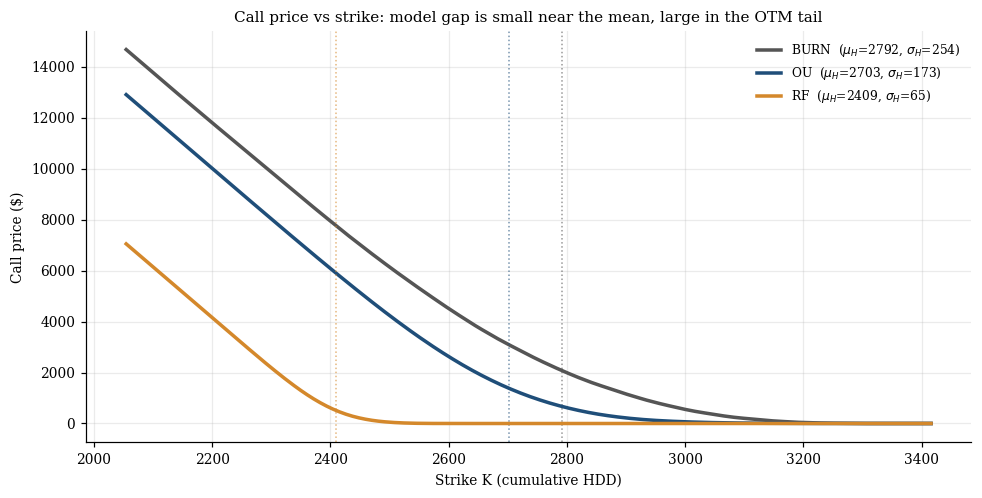

In [7]:
disc = np.exp(-R * ttm)
strike_models = ["burn", "ou", "rf"]              # contrast the dispersions (wide to narrow)
Kgrid = np.linspace(min(H[m].min() for m in strike_models),
                    max(H[m].max() for m in strike_models), 250)
price_curve = lambda Hm: TICK * disc * np.maximum(Hm[:, None] - Kgrid[None, :], 0).mean(axis=0)

fig, ax = plt.subplots(figsize=(9, 4.6))
for m in strike_models:
    ax.plot(Kgrid, price_curve(H[m]), color=COLORS[m], lw=2.3,
            label=f"{m.upper()}  ($\\mu_H$={H[m].mean():.0f}, $\\sigma_H$={H[m].std():.0f})")
    ax.axvline(H[m].mean(), color=COLORS[m], ls=":", lw=1, alpha=0.6)
ax.set_xlabel("Strike K (cumulative HDD)"); ax.set_ylabel("Call price ($)")
ax.set_title("Call price vs strike: model gap is small near the mean, large in the OTM tail")
ax.legend(fontsize=8, frameon=False); fig.tight_layout()

# Part B: the economic backtest

We confront each model's *price* with the *realized payoff* across the 35 contracts. 

The realized payoff $Y$ is a single draw, so this lens has an irreducible noise floor and is sensitive to the benchmark, so it is *suggestive*. The strike here uses a **recent** burn window (anti cold-bias).

Payoff > 0 in 13 / 35 cells (the cold winters)


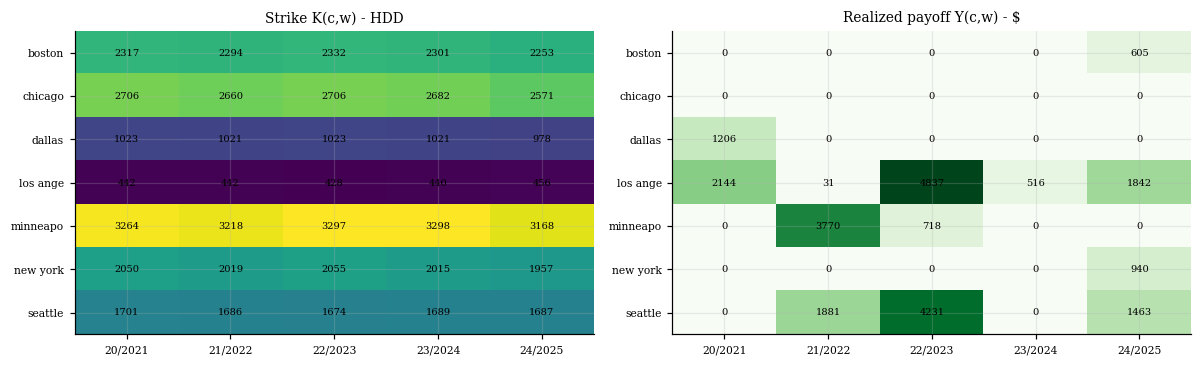

In [8]:
def mat(model, value):
    return (res[res.model == model].pivot(index="city", columns="winter", values=value)
            .reindex(index=CITIES, columns=WINTERS))

def heatmap(ax, M, title, cmap, vmin=None, vmax=None):
    d = M.values.astype(float)
    im = ax.imshow(d, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(M.shape[1]), [w[2:] for w in M.columns], fontsize=7)
    ax.set_yticks(range(M.shape[0]), [c.replace("_", " ")[:8] for c in M.index], fontsize=7)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if np.isfinite(d[i, j]):
                ax.text(j, i, f"{d[i,j]:.0f}", ha="center", va="center", fontsize=6.5)
    ax.set_title(title, fontsize=9); return im

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
heatmap(axes[0], mat("burn", "K"), "Strike K(c,w) - HDD", "viridis")
heatmap(axes[1], mat("burn", "payoff_real"), "Realized payoff Y(c,w) - $", "Greens")
fig.tight_layout()
print(f"Payoff > 0 in {(mat('burn','payoff_real').values > 0).sum()} / 35 cells (the cold winters)")

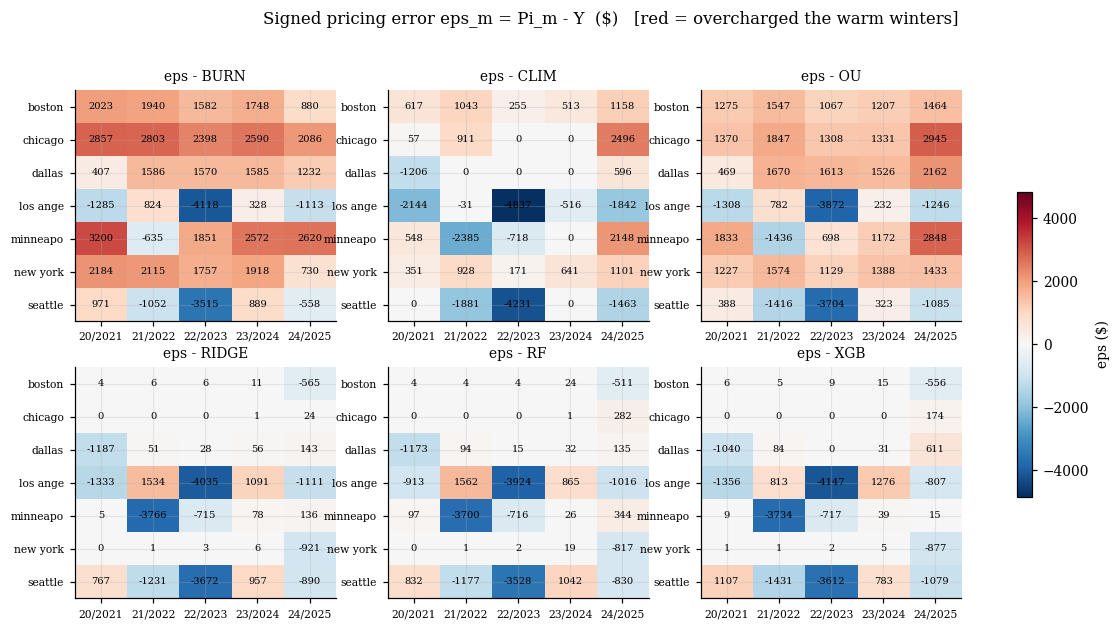

In [9]:
Y = mat("burn", "payoff_real")
eps = {m: mat(m, "call_price") - Y for m in MODELS}
a = max(np.nanmax(np.abs(e.values)) for e in eps.values())
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, m in zip(axes.flat, MODELS):
    im = heatmap(ax, eps[m], f"eps - {m.upper()}", "RdBu_r", vmin=-a, vmax=a)
fig.suptitle("Signed pricing error eps_m = Pi_m - Y  ($)   [red = overcharged the warm winters]", y=1.0)
fig.colorbar(im, ax=axes, shrink=0.6, label="eps ($)"); plt.show()

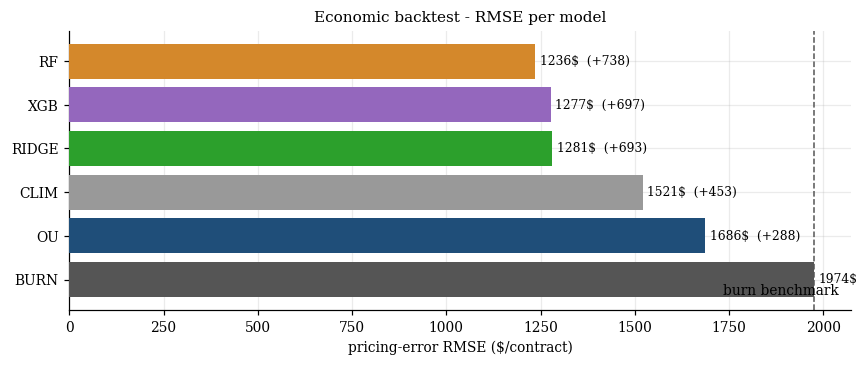

In [10]:
rmse = pd.Series({m: np.sqrt(np.nanmean(eps[m].values ** 2)) for m in MODELS}).sort_values()
gain = rmse["burn"] - rmse
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh(range(len(rmse)), rmse.values, color=[COLORS[m] for m in rmse.index], zorder=3)
ax.axvline(rmse["burn"], color="#555", ls="--", lw=1, label="burn benchmark")
ax.set_yticks(range(len(rmse)), [m.upper() for m in rmse.index]); ax.invert_yaxis()
for i, (m, v) in enumerate(rmse.items()):
    ax.text(v + 12, i, f"{v:.0f}$" + (f"  ({gain[m]:+.0f})" if m != "burn" else ""), va="center", fontsize=8)
ax.set_xlabel("pricing-error RMSE ($/contract)"); ax.set_title("Economic backtest - RMSE per model")
ax.legend(frameon=False, loc="lower right"); fig.tight_layout()

### Robustness to the strike (moneyness sweep)

The strike was set ATM ($K$ = 10-year burn mean). But $K$ decides *which moment the
contest probes*: deep ITM rewards the **mean** $\mu_H$, OTM rewards the **dispersion**
$\sigma_H$ (only the tail clears $K$). We re-price every cell at
$K=\text{ATM}\times\{0.90\ldots1.10\}$ and recompute the RMSE. If the ranking flips
with $K$, the economic verdict would be strike-dependent.

model,burn,clim,ou,ridge,rf,xgb,best
moneyness,,,,,,,
0.90,3129.0,3148.0,3193.0,2419.0,2393.0,2465.0,rf
0.95,2599.0,2360.0,2470.0,1900.0,1851.0,1928.0,rf
1.00,1974.0,1521.0,1686.0,1279.0,1240.0,1288.0,rf
1.05,1302.0,948.0,1019.0,893.0,853.0,899.0,rf
1.10,879.0,742.0,711.0,725.0,690.0,722.0,rf


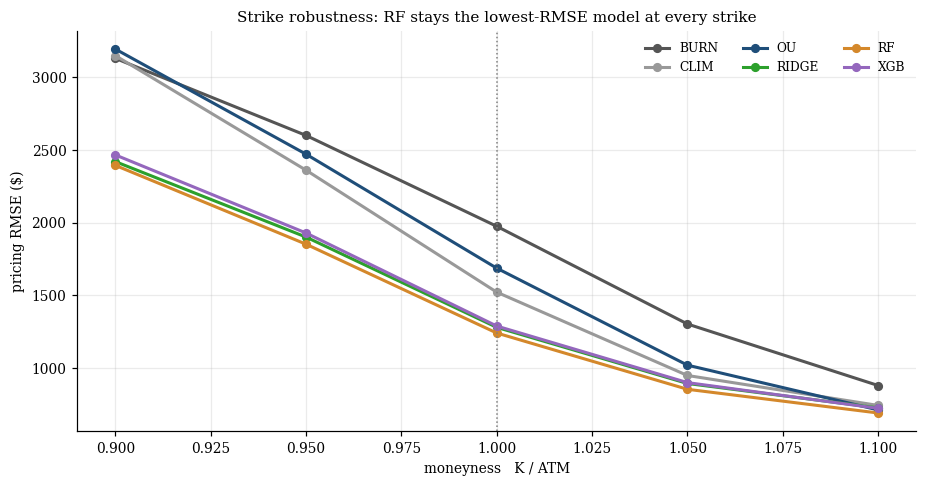

In [12]:
rk = pd.read_csv("../outputs/pricing_contest_strikes.csv")
rob = (rk.groupby(["moneyness", "model"])
         .apply(lambda d: np.sqrt(np.mean((d.call_price - d.payoff_real) ** 2)))
         .unstack()[MODELS].round(0))
display(rob.assign(best=rob.idxmin(axis=1)))

fig, ax = plt.subplots(figsize=(8.5, 4.5))
for m in MODELS:
    ax.plot(rob.index, rob[m], "o-", color=COLORS[m], lw=2, ms=5, label=m.upper())
ax.axvline(1.0, color="grey", ls=":", lw=1)
ax.set_xlabel("moneyness   K / ATM"); ax.set_ylabel("pricing RMSE ($)")
ax.set_title("Strike robustness: RF stays the lowest-RMSE model at every strike")
ax.legend(fontsize=8, frameon=False, ncol=3); fig.tight_layout()

RF is the lowest-RMSE model at **every** strike (0.90 → 1.10): the ranking is **robust** to the strike, not an artefact of the ATM choice. The dollar margin is largest around ITM/ATM and **compresses deep OTM**, where every call expires near zero and the OU catches up. The *mechanism* is unchanged though: at every strike the warm 2020 to 25 winters reward under-pricing, so this strengthens the **ranking**, not the interpretation. **Part A stays primary.**

# Synthesis: what the model choice is worth, in risk and in dollars

| Model | σ_H (dispersion) | Realized pricing RMSE |
|---|---|---|
| **burn (desk)** | reference, σ_H ≈ 205 to 228 (detrended / normal) | worst, RMSE ≈ 1974\$ |
| **OU** | narrower, σ_H ≈ 130 | RMSE ≈ 1686\$ |
| **ML (rf)** | narrowest, σ_H ≈ 53 | **best**, RMSE ≈ 1240\$ |

The two views point in *opposite* directions on the ML, and reconciling them is the conclusion:

- **σ_H (what sets the price).** Every conditional model is narrower than both desk burns. For the ML this narrowness is **not intrinsic**: a Random Forest is a deterministic point forecaster with no $σ_H$, and the dispersion is **manufactured by the i.i.d. Monte-Carlo generator**.

- **Realized backtest.** The ML posts the lowest RMSE, but 2020 to 25 winters were **warm** ($Y\approx0$), so a low price carries a small realized error. A single realized payoff is a noise-floor judge, not pricing quality, and the gap is benchmark-fragile.